In [2]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'customers.csv', 'Untitled.ipynb']


In [3]:
import pandas as pd

df = pd.read_csv("customers.csv")

print(df)

   CustomerID  Income  SpendingScore
0       86769  15,000             39
1       45745  24,232             81
2       54467  23,214              6
3       42524  18,000             77
4       23553  19,000             40
5       23552  20,000             76
6       54252  21,900              6
7       52252  22,020             94
8       25522  23,000              3
9       11330  24,500             72


In [5]:
pip install pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


C:\anconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   CustomerID   Income  SpendingScore  Cluster
0       86769  15000.0           39.0        2
1       45745  24232.0           81.0        1
2       54467  23214.0            6.0        1
3       42524  18000.0           77.0        0
4       23553  19000.0           40.0        0
5       23552  20000.0           76.0        0
6       54252  21900.0            6.0        1
7       52252  22020.0           94.0        1
8       25522  23000.0            3.0        1
9       11330  24500.0           72.0        1


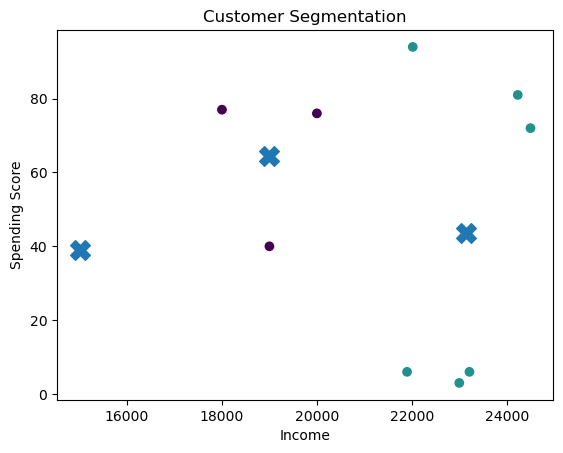

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("customers.csv")

# Remove commas from Income column
df["Income"] = df["Income"].astype(str).str.replace(",", "")

# Convert to numbers
df["Income"] = df["Income"].astype(float)
df["SpendingScore"] = df["SpendingScore"].astype(float)

# Select features
X = df[["Income", "SpendingScore"]]

# Create KMeans model
kmeans = KMeans(n_clusters=3, random_state=42)

# Predict clusters
df["Cluster"] = kmeans.fit_predict(X)

# Print results
print(df)

# Plot graph
plt.scatter(
    df["Income"],
    df["SpendingScore"],
    c=df["Cluster"]
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

# Labels
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

df.to_csv("customers_clustered.csv", index=False)

# Show graph
plt.show()